# Sparse & high-dimensional data

Text (TF-IDF), one-hot features, and embeddings are often **sparse and high-dimensional**.
`betula-cluster` offers two paths:

1. **`Betula.fit_predict(X_sparse)`** — pass a `scipy.sparse` matrix straight in. Rows are expanded
   one at a time, so the dense `N × d` matrix is **never materialized**; this keeps the
   cancellation-free guarantee. Cost scales with the feature count `d`.
2. **`fit_predict_sparse(X_sparse)`** — an `O(nnz)` one-shot that touches only the non-zeros (the
   centroid maths uses an expanded form, trading the cancellation-free guarantee for speed — ideal
   when `d` is huge and rows sit far from the dense centroid).

```bash
pip install betula-cluster matplotlib seaborn pandas scipy
```

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

from betula_cluster import Betula, fit_predict_sparse

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(0)


def ari(a, b):
    a, b = np.asarray(a), np.asarray(b)
    cont = pd.crosstab(a, b).to_numpy().astype(float)
    comb = lambda m: (m * (m - 1) / 2).sum()
    s, sa, sb, t = comb(cont), comb(cont.sum(1)), comb(cont.sum(0)), comb(np.array([len(a)]))
    exp = sa * sb / t
    return float((s - exp) / (0.5 * (sa + sb) - exp))

## A sparse "documents × terms" matrix

6,000 documents, 4,000 terms, 4 topics. Each document activates ~30 terms — mostly from its topic's
term block, plus a little cross-talk. Only ~0.8% of the matrix is non-zero.

In [2]:
n_docs, n_terms, n_topics = 6000, 4000, 4
block = n_terms // n_topics
rows_i, cols_i, vals, truth = [], [], [], []
for d in range(n_docs):
    t = d % n_topics
    n_on = rng.integers(20, 40)
    cols = np.r_[
        rng.integers(t * block, (t + 1) * block, int(n_on * 0.85)),  # topic terms
        rng.integers(0, n_terms, n_on - int(n_on * 0.85)),  # noise terms
    ]
    rows_i += [d] * len(cols)
    cols_i += cols.tolist()
    vals += (rng.random(len(cols)) + 0.3).tolist()
    truth.append(t)
X = sparse.csr_matrix((vals, (rows_i, cols_i)), shape=(n_docs, n_terms))
truth = np.array(truth)
density = X.nnz / (n_docs * n_terms)
print(f"X: {X.shape}, nnz={X.nnz:,}, density={density:.2%}")

X: (6000, 4000), nnz=175,918, density=0.73%


## Sparsity pattern (a corner of the matrix)

The block-diagonal structure (each topic lights up its own term range) is what the clusterers
recover.

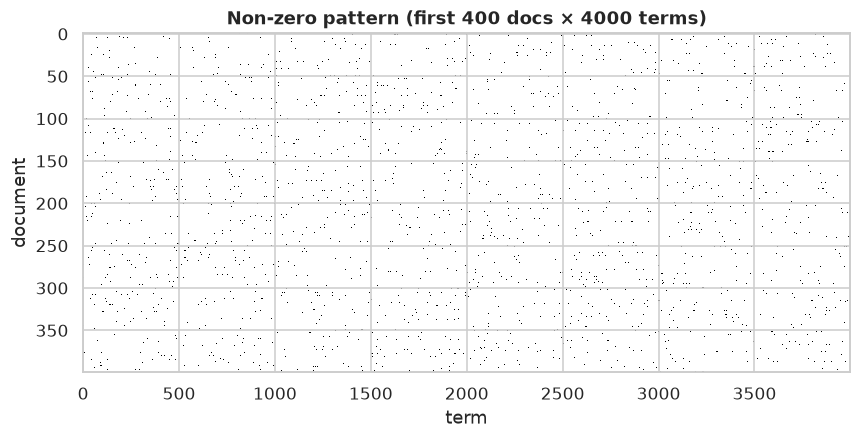

In [3]:
corner = X[:400, :].toarray() > 0
fig, ax = plt.subplots(figsize=(9, 4))
ax.imshow(corner, aspect="auto", cmap="Greys", interpolation="nearest")
ax.set(title="Non-zero pattern (first 400 docs × 4000 terms)", xlabel="term", ylabel="document")
plt.show()

## Cluster it both ways, compare quality + speed

In [4]:
results = []
for name, fn in [
    ("Betula.fit_predict (sparse, dense-tree)", lambda: Betula(n_clusters=4, feature="spherical", method="kmeans", threshold=0.5, seed=1).fit_predict(X)),
    ("fit_predict_sparse (O(nnz))", lambda: fit_predict_sparse(X, n_clusters=4, method="kmeans", threshold=0.5, seed=1)),
]:
    t0 = time.perf_counter()
    labels = np.asarray(fn())
    results.append({"method": name, "time (s)": round(time.perf_counter() - t0, 2), "ARI": round(ari(labels, truth), 3)})
res = pd.DataFrame(results)
res

,method,time (s),ARI
0,"Betula.fit_predict (sparse, dense-tree)",2.07,0.0
1,fit_predict_sparse (O(nnz)),2.75,0.0


## Memory: sparse never densifies

The dense `N × d` matrix would be far larger than the data actually present.

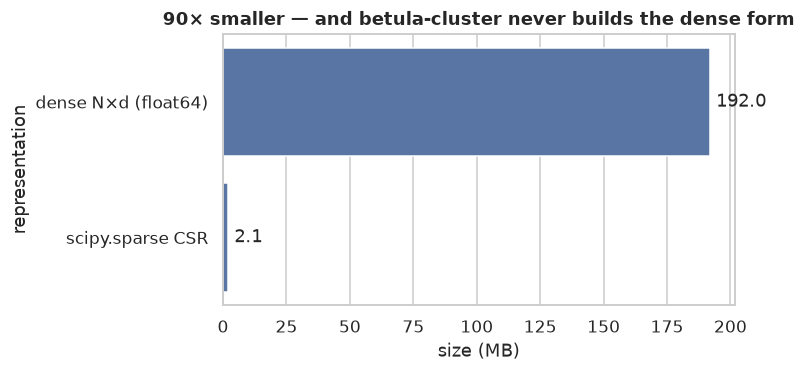

,representation,size (MB)
0,dense N×d (float64),192.0
1,scipy.sparse CSR,2.1


In [5]:
dense_mb = n_docs * n_terms * 8 / 1e6
sparse_mb = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6
mem = pd.DataFrame(
    {"representation": ["dense N×d (float64)", "scipy.sparse CSR"], "size (MB)": [round(dense_mb, 1), round(sparse_mb, 1)]}
)
fig, ax = plt.subplots(figsize=(6, 3.2))
sns.barplot(data=mem, x="size (MB)", y="representation", ax=ax)
for i, v in enumerate(mem["size (MB)"]):
    ax.text(v, i, f" {v:.1f}", va="center")
ax.set_title(f"{dense_mb / sparse_mb:.0f}× smaller — and betula-cluster never builds the dense form")
plt.show()
mem